# SaaS Product Funnel Analytics

This project analyzes user behavior across a SaaS product funnel using Python, SQL, and Power BI.

The project focuses on:
- user onboarding
- engagement analysis
- retention analysis
- churn analysis
- subscription conversion
- revenue insights
- product funnel analytics

## Project Objective

The objective of this project is to simulate and analyze SaaS user journey behavior to identify:
- funnel drop-offs
- user engagement patterns
- subscription conversion trends
- retention performance
- churn behavior
- revenue opportunities

## Business Problem

SaaS companies need to understand how users move through the product funnel from signup to premium subscription.

This analysis helps identify:
- onboarding bottlenecks
- low engagement users
- churned users
- premium conversion behavior
- high-value customer segments

## Tools and Technologies Used

- Python
- Pandas
- NumPy
- Faker
- Matplotlib
- MySQL
- Power BI

## Notebook Workflow

This notebook includes:

1. Library installation  
2. Library imports  
3. Synthetic SaaS dataset generation  
4. Dataset export  
5. Data loading  
6. Exploratory Data Analysis  
7. Funnel analysis  
8. Churn analysis  
9. Retention analysis  
10. Revenue and feature usage analysis

## I. Install Required Libraries

The Faker library is used to generate realistic synthetic user data for the SaaS product funnel dataset.

In [24]:
!pip install faker


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 24.6 MB/s eta 0:00:00


## II. Import Required Libraries

The required libraries are imported for data generation, data analysis, and visualization.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from faker import Faker
from datetime import timedelta
import random

## III. Synthetic Dataset Generation

In this section, synthetic SaaS user data is generated to simulate a real-world product funnel.  
The dataset includes user signup behavior, onboarding progress, feature usage, subscription status, revenue, retention, and churn information.

In [ ]:
import pandas as pd
import numpy as np
from faker import Faker
from datetime import timedelta
import random

# -----------------------------------
# INITIAL SETUP
# -----------------------------------
fake = Faker()

NUM_USERS = 25000

countries = [
    "India",
    "USA",
    "UK",
    "Germany",
    "Canada",
    "Australia"
]

device_types = [
    "Desktop",
    "Mobile",
    "Tablet"
]

traffic_sources = [
    "Organic Search",
    "Google Ads",
    "LinkedIn",
    "Referral",
    "Direct",
    "Email Campaign"
]

features = [
    "Task Management",
    "Team Collaboration",
    "Analytics Dashboard",
    "File Sharing",
    "Workflow Automation",
    "Calendar Integration"
]

plan_types = [
    "Basic",
    "Pro",
    "Enterprise"
]

# -----------------------------------
# DATA STORAGE
# -----------------------------------
data = []

# -----------------------------------
# GENERATE USERS
# -----------------------------------
for user_id in range(1, NUM_USERS + 1):

    signup_date = fake.date_between(
        start_date='-1y',
        end_date='today'
    )

    country = random.choice(countries)

    device_type = random.choice(device_types)

    traffic_source = random.choice(traffic_sources)

    # -----------------------------------
    # FUNNEL LOGIC
    # -----------------------------------

    email_verified = np.random.choice(
        [True, False],
        p=[0.80, 0.20]
    )

    workspace_created = (
        True if email_verified and random.random() < 0.70
        else False
    )

    onboarding_completed = (
        True if workspace_created and random.random() < 0.75
        else False
    )

    # -----------------------------------
    # FEATURE USAGE
    # -----------------------------------

    if onboarding_completed:

        first_feature_used = random.choice(features)

        feature_usage_count = np.random.randint(5, 200)

        total_sessions = np.random.randint(10, 500)

        login_frequency = random.choice([
            "Daily",
            "Weekly",
            "Monthly"
        ])

    else:

        first_feature_used = None

        feature_usage_count = 0

        total_sessions = 0

        login_frequency = "Rare"

    # -----------------------------------
    # SUBSCRIPTION LOGIC
    # -----------------------------------

    subscription_type = np.random.choice(
        ["Free", "Premium"],
        p=[0.85, 0.15]
    )

    if subscription_type == "Premium":

        subscription_date = signup_date + timedelta(
            days=random.randint(1, 60)
        )

        monthly_revenue = random.choice([
            10,
            20,
            30,
            50
        ])

        avg_session_duration = round(
            np.random.uniform(25, 90),
            2
        )

        plan_type = random.choice(plan_types)

    else:

        subscription_date = None

        monthly_revenue = 0

        avg_session_duration = round(
            np.random.uniform(5, 45),
            2
        )

        plan_type = "Free"

    # -----------------------------------
    # RETENTION & CHURN
    # -----------------------------------

    churn_status = np.random.choice(
        ["Active", "Churned"],
        p=[0.65, 0.35]
    )

    active_status = (
        "Active User"
        if churn_status == "Active"
        else "Inactive User"
    )

    retention_days = np.random.randint(1, 365)

    cohort_month = signup_date.strftime("%Y-%m")

    # -----------------------------------
    # LAST LOGIN
    # -----------------------------------

    if churn_status == "Active":

        last_login_date = fake.date_between(
            start_date='-30d',
            end_date='today'
        )

    else:

        last_login_date = fake.date_between(
            start_date='-180d',
            end_date='-31d'
        )

    # -----------------------------------
    # APPEND DATA
    # -----------------------------------

    data.append([
        user_id,
        signup_date,
        cohort_month,
        country,
        device_type,
        traffic_source,
        email_verified,
        workspace_created,
        onboarding_completed,
        first_feature_used,
        feature_usage_count,
        total_sessions,
        login_frequency,
        avg_session_duration,
        subscription_type,
        plan_type,
        subscription_date,
        monthly_revenue,
        retention_days,
        last_login_date,
        churn_status,
        active_status
    ])

# -----------------------------------
# CREATE DATAFRAME
# -----------------------------------

columns = [
    "user_id",
    "signup_date",
    "cohort_month",
    "country",
    "device_type",
    "traffic_source",
    "email_verified",
    "workspace_created",
    "onboarding_completed",
    "first_feature_used",
    "feature_usage_count",
    "total_sessions",
    "login_frequency",
    "avg_session_duration",
    "subscription_type",
    "plan_type",
    "subscription_date",
    "monthly_revenue",
    "retention_days",
    "last_login_date",
    "churn_status",
    "active_status"
]

df = pd.DataFrame(data, columns=columns)

# -----------------------------------
# EXPORT CSV
# -----------------------------------

df.to_csv(
    "saas_user_funnel_dataset.csv",
    index=False
)

# -----------------------------------
# SUCCESS MESSAGE
# -----------------------------------

print("Advanced SaaS Dataset Generated Successfully 🚀")
print(df.head())

Advanced SaaS Dataset Generated Successfully 🚀
   user_id signup_date cohort_month    country device_type  traffic_source  \
0        1  2025-06-23      2025-06  Australia      Tablet      Google Ads   
1        2  2026-02-25      2026-02        USA      Mobile          Direct   
2        3  2025-09-03      2025-09        USA     Desktop  Organic Search   
3        4  2025-10-08      2025-10         UK     Desktop  Email Campaign   
4        5  2025-07-11      2025-07         UK      Tablet          Direct   

   email_verified  workspace_created  onboarding_completed  \
0            True               True                  True   
1            True               True                 False   
2            True               True                  True   
3            True              False                 False   
4            True              False                 False   

    first_feature_used  ...  login_frequency  avg_session_duration  \
0         File Sharing  ...            Da

In [ ]:
df.shape

(25000, 22)

## IV. Export Generated Dataset

The generated dataset is saved as a CSV file so it can be used later for SQL analysis, Power BI dashboarding, and further EDA.

In [ ]:
from google.colab import files
files.download("saas_user_funnel_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# SaaS Product Funnel Analytics

This notebook performs exploratory data analysis on a synthetic SaaS product dataset.  
The analysis focuses on user onboarding, product engagement, retention, churn, subscription conversion, and revenue performance.

## 1. Upload Dataset

We upload the required dataset for data analysis and visualization.


In [26]:
from google.colab import files

uploaded = files.upload()

Saving saas_user_funnel_dataset.csv to saas_user_funnel_dataset (1).csv


## 6. Load Dataset

The generated SaaS product funnel dataset is loaded into a Pandas DataFrame for analysis.

In [4]:
df = pd.read_csv("saas_user_funnel_dataset.csv")

df.head()


,user_id,signup_date,cohort_month,country,device_type,traffic_source,email_verified,workspace_created,onboarding_completed,first_feature_used,...,login_frequency,avg_session_duration,subscription_type,plan_type,subscription_date,monthly_revenue,retention_days,last_login_date,churn_status,active_status
0,1,2025-06-23,2025-06,Australia,Tablet,Google Ads,True,True,True,File Sharing,...,Daily,32.36,Free,Free,NaN,0,361,2026-04-30,Active,Active User
1,2,2026-02-25,2026-02,USA,Mobile,Direct,True,True,False,NaN,...,Rare,29.28,Free,Free,NaN,0,55,2026-01-31,Churned,Inactive User
2,3,2025-09-03,2025-09,USA,Desktop,Organic Search,True,True,True,Analytics Dashboard,...,Monthly,40.56,Free,Free,NaN,0,77,2026-05-03,Active,Active User
3,4,2025-10-08,2025-10,UK,Desktop,Email Campaign,True,False,False,NaN,...,Rare,32.71,Free,Free,NaN,0,349,2026-05-07,Active,Active User
4,5,2025-07-11,2025-07,UK,Tablet,Direct,True,False,False,NaN,...,Rare,32.52,Free,Free,NaN,0,332,2026-05-18,Active,Active User


## 3. Dataset Shape

This shows the total number of rows and columns in the dataset.

## 7. Dataset Shape

This shows the total number of rows and columns in the dataset.

In [5]:
df.shape

(25000, 22)

## 4. Dataset Information

This helps us understand column names, data types, and non-null values.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               25000 non-null  int64  
 1   signup_date           25000 non-null  object 
 2   cohort_month          25000 non-null  object 
 3   country               25000 non-null  object 
 4   device_type           25000 non-null  object 
 5   traffic_source        25000 non-null  object 
 6   email_verified        25000 non-null  bool   
 7   workspace_created     25000 non-null  bool   
 8   onboarding_completed  25000 non-null  bool   
 9   first_feature_used    10598 non-null  object 
 10  feature_usage_count   25000 non-null  int64  
 11  total_sessions        25000 non-null  int64  
 12  login_frequency       25000 non-null  object 
 13  avg_session_duration  25000 non-null  float64
 14  subscription_type     25000 non-null  object 
 15  plan_type          

## 5. Missing Value Check

This checks whether any column contains missing values.

In [7]:
df.isnull().sum()

,0
user_id,0
signup_date,0
cohort_month,0
country,0
device_type,0
traffic_source,0
email_verified,0
workspace_created,0
onboarding_completed,0
first_feature_used,14402


## 6. Statistical Summary

This gives a basic statistical summary of numerical columns such as session duration, revenue, retention days, total sessions, and feature usage count.

In [8]:
df.describe()

,user_id,feature_usage_count,total_sessions,avg_session_duration,monthly_revenue,retention_days
count,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000
mean,12500.500000,43.098200,107.65164,29.964050,4.110800,183.201960
std,7217.022701,62.187842,155.58774,17.276373,11.350704,105.485512
min,1.000000,0.000000,0.00000,5.000000,0.000000,1.000000
25%,6250.750000,0.000000,0.00000,16.900000,0.000000,91.000000
50%,12500.500000,0.000000,0.00000,28.380000,0.000000,184.000000
75%,18750.250000,84.000000,209.00000,38.910000,0.000000,275.000000
max,25000.000000,199.000000,499.00000,89.940000,50.000000,364.000000


## 7. Funnel Stage Counts

This section calculates how many users reached each stage of the SaaS product funnel.

In [9]:
total_users = len(df)
verified_users = df[df["email_verified"] == True].shape[0]
workspace_users = df[df["workspace_created"] == True].shape[0]
onboarded_users = df[df["onboarding_completed"] == True].shape[0]
premium_users = df[df["subscription_type"] == "Premium"].shape[0]

funnel_counts = pd.DataFrame({
    "Stage": [
        "Total Users",
        "Email Verified",
        "Workspace Created",
        "Onboarding Completed",
        "Premium Users"
    ],
    "Users": [
        total_users,
        verified_users,
        workspace_users,
        onboarded_users,
        premium_users
    ]
})

funnel_counts

,Stage,Users
0,Total Users,25000
1,Email Verified,20070
2,Workspace Created,14022
3,Onboarding Completed,10598
4,Premium Users,3716


## 8. Funnel Conversion Visualization

This chart shows user drop-off across the SaaS product funnel.

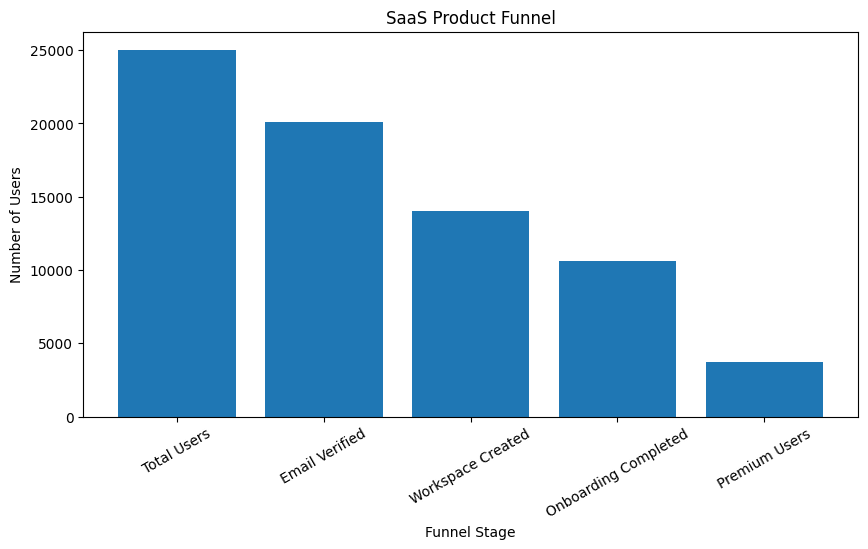

In [10]:
plt.figure(figsize=(10, 5))
plt.bar(funnel_counts["Stage"], funnel_counts["Users"])
plt.title("SaaS Product Funnel")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Users")
plt.xticks(rotation=30)
plt.show()

## 9. Churn Analysis

This section analyzes active and churned users.

In [11]:
churn_counts = df["churn_status"].value_counts()

churn_counts

,count
churn_status,
Active,16346
Churned,8654


## 10. Churn Visualization

This chart shows the distribution of active and churned users.

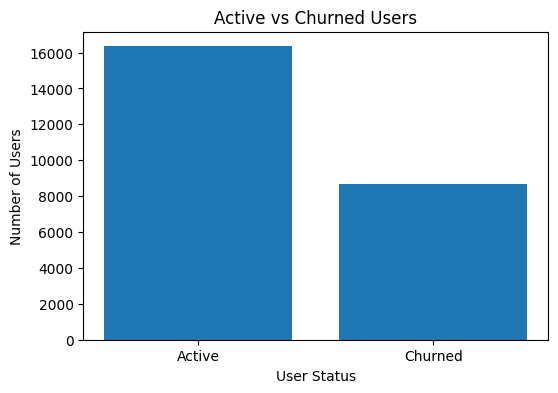

In [12]:
plt.figure(figsize=(6, 4))
plt.bar(churn_counts.index, churn_counts.values)
plt.title("Active vs Churned Users")
plt.xlabel("User Status")
plt.ylabel("Number of Users")
plt.show()

## 11. Subscription Analysis

This section compares free and premium users.

In [13]:
subscription_counts = df["subscription_type"].value_counts()

subscription_counts

,count
subscription_type,
Free,21284
Premium,3716


## 12. Revenue by Plan Type

This section analyzes total revenue generated by each subscription plan.

In [14]:
revenue_by_plan = df.groupby("plan_type")["monthly_revenue"].sum().sort_values(ascending=False)

revenue_by_plan

,monthly_revenue
plan_type,
Basic,35070
Pro,33930
Enterprise,33770
Free,0


## 13. Revenue Visualization

This chart shows which plan type contributes the most revenue.

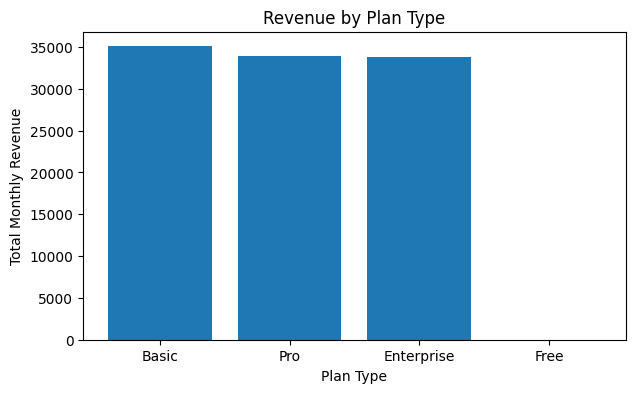

In [15]:
plt.figure(figsize=(7, 4))
plt.bar(revenue_by_plan.index, revenue_by_plan.values)
plt.title("Revenue by Plan Type")
plt.xlabel("Plan Type")
plt.ylabel("Total Monthly Revenue")
plt.show()

## 14. Feature Usage Analysis

This section identifies the most commonly used first feature among onboarded users.

In [17]:
feature_usage = df["first_feature_used"].value_counts()

feature_usage

,count
first_feature_used,
Calendar Integration,1817
Workflow Automation,1817
Analytics Dashboard,1759
Team Collaboration,1740
Task Management,1737
File Sharing,1728


## 15. Feature Usage Visualization

This chart shows the most adopted SaaS product features.

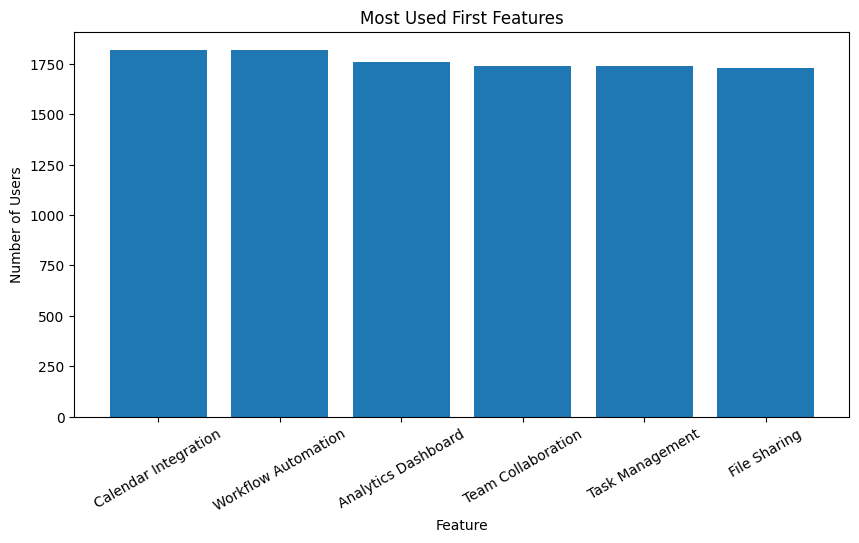

In [18]:
plt.figure(figsize=(10, 5))
plt.bar(feature_usage.index, feature_usage.values)
plt.title("Most Used First Features")
plt.xlabel("Feature")
plt.ylabel("Number of Users")
plt.xticks(rotation=30)
plt.show()

## 16. Traffic Source Analysis

This section analyzes which traffic sources bring the most users.

In [19]:
traffic_counts = df["traffic_source"].value_counts()

traffic_counts

,count
traffic_source,
Referral,4223
Organic Search,4187
Email Campaign,4185
LinkedIn,4170
Google Ads,4128
Direct,4107


## 17. Traffic Source Visualization

This chart shows user acquisition by traffic source.

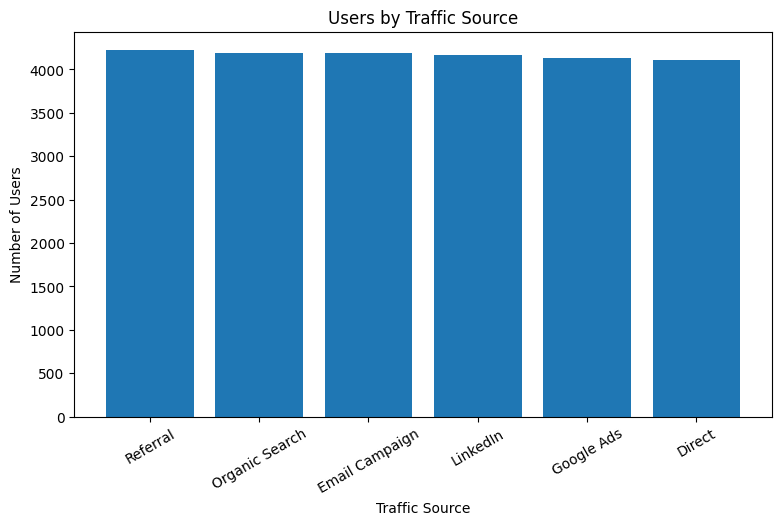

In [20]:
plt.figure(figsize=(9, 5))
plt.bar(traffic_counts.index, traffic_counts.values)
plt.title("Users by Traffic Source")
plt.xlabel("Traffic Source")
plt.ylabel("Number of Users")
plt.xticks(rotation=30)
plt.show()

## 18. Retention Analysis

This section analyzes average retention days by subscription type.

In [21]:
retention_by_subscription = df.groupby("subscription_type")["retention_days"].mean().round(2)

retention_by_subscription

,retention_days
subscription_type,
Free,183.32
Premium,182.50


## 19. Retention Visualization

This chart compares average retention between free and premium users.

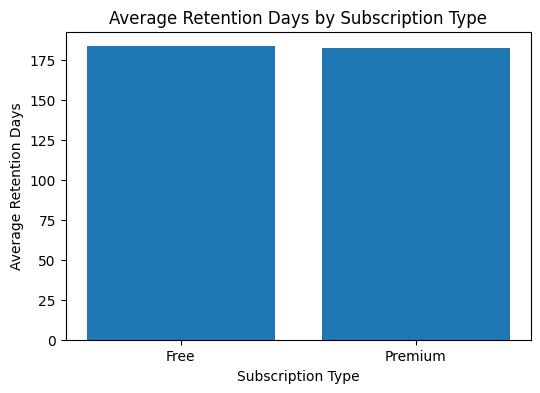

In [22]:
plt.figure(figsize=(6, 4))
plt.bar(retention_by_subscription.index, retention_by_subscription.values)
plt.title("Average Retention Days by Subscription Type")
plt.xlabel("Subscription Type")
plt.ylabel("Average Retention Days")
plt.show()

## 20. Key Findings

Based on the initial EDA, this project analyzes user movement across the SaaS funnel, identifies churn behavior, compares free vs premium users, studies feature adoption, and evaluates revenue contribution by plan type.

These findings will later be used to build the Power BI dashboard and final business recommendations.

## 17. Business Recommendations

Based on the analysis performed on the SaaS product funnel dataset, the following business recommendations are suggested:

- Improve onboarding flow to reduce user drop-off between signup and workspace creation stages.

- Increase engagement for low-activity users through personalized onboarding and feature guidance.

- Focus marketing efforts on high-performing traffic sources that bring higher premium conversion rates.

- Encourage free users to upgrade by offering targeted premium feature campaigns and trial experiences.

- Reduce churn by identifying low-retention users and improving user engagement strategies.

- Optimize feature adoption by promoting the most valuable and frequently used product features.

- Improve retention by increasing user interaction frequency and session engagement.

- Analyze premium user behavior further to identify characteristics of high-value customers.

## 18. Churn by Device Type

This section analyzes churn distribution across different device types.

In [27]:
# churn by device type

churn_by_device = df.groupby("device_type")["churn_status"].value_counts()

churn_by_device

device_type  churn_status
Desktop      Active          5464
             Churned         2875
Mobile       Active          5430
             Churned         2817
Tablet       Active          5452
             Churned         2962
Name: count, dtype: int64

## 19. Churn by Device Visualization

This chart shows churn behavior across desktop, mobile, and tablet users.

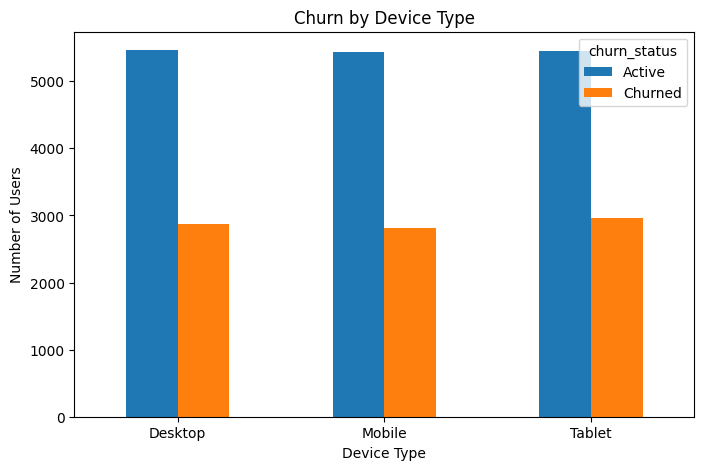

In [28]:
# churn visualization by device

churn_device_chart = pd.crosstab(
    df["device_type"],
    df["churn_status"]
)
churn_device_chart.plot(kind="bar", figsize=(8,5))
plt.title("Churn by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Number of Users")
plt.xticks(rotation=0)
plt.show()

## 20. Revenue by Traffic Source

This section analyzes which traffic sources generate the highest revenue.

In [29]:
# revenue by traffic source

revenue_by_source = df.groupby("traffic_source")[
    "monthly_revenue"
].sum().sort_values(ascending=False)

revenue_by_source

,monthly_revenue
traffic_source,
Organic Search,17850
Direct,17410
Email Campaign,17240
Referral,17160
Google Ads,16580
LinkedIn,16530


## 21. Revenue by Traffic Source Visualization

This chart shows revenue contribution from different traffic channels.

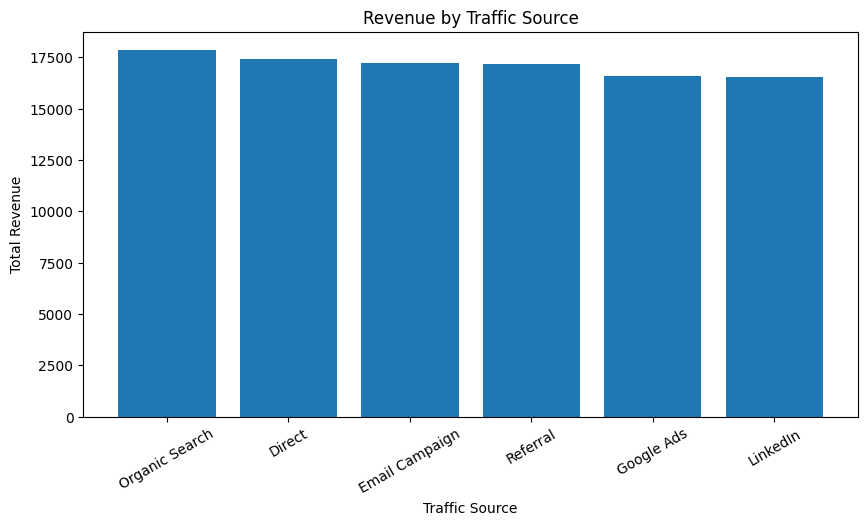

In [30]:
# revenue chart

plt.figure(figsize=(10,5))

plt.bar(
    revenue_by_source.index,
    revenue_by_source.values
)
plt.title("Revenue by Traffic Source")
plt.xlabel("Traffic Source")
plt.ylabel("Total Revenue")
plt.xticks(rotation=30)
plt.show()

## 22. Cohort Analysis

This section analyzes monthly user signup cohorts.

In [31]:
# cohort analysis

cohort_analysis = df["cohort_month"].value_counts().sort_index()

cohort_analysis

,count
cohort_month,
2025-05,734
2025-06,1998
2025-07,2134
2025-08,2155
2025-09,2008
2025-10,2134
2025-11,2047
2025-12,2128
2026-01,2188


## 23. Cohort Visualization

This chart shows monthly user acquisition trends.

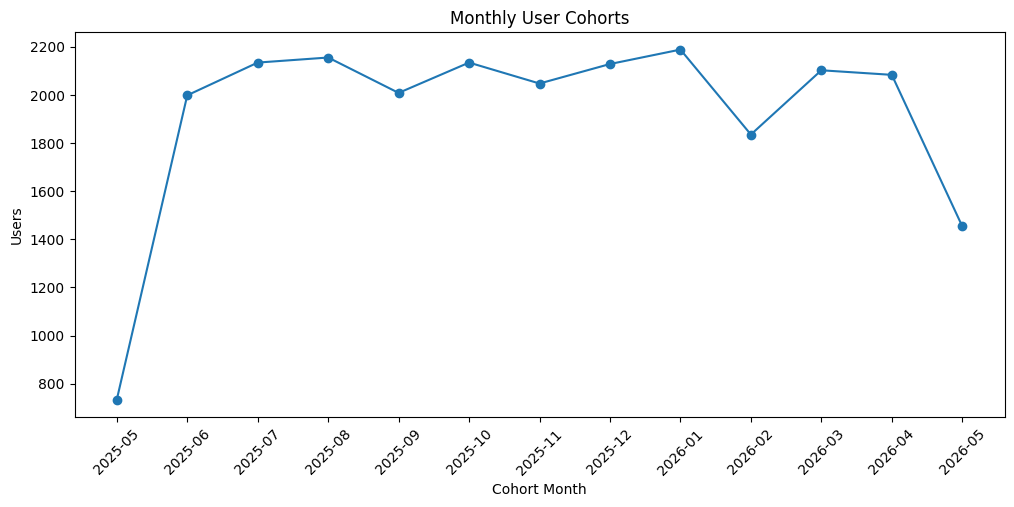

In [32]:
# cohort chart

plt.figure(figsize=(12,5))

plt.plot(
    cohort_analysis.index,
    cohort_analysis.values,
    marker='o'
)
plt.title("Monthly User Cohorts")
plt.xlabel("Cohort Month")
plt.ylabel("Users")
plt.xticks(rotation=45)
plt.show()

## 24. Retention Group Analysis

This section categorizes users based on retention duration.

In [33]:
# retention groups

df["retention_group"] = np.where(
    df["retention_days"] <= 30,
    "0-30 Days",

    np.where(
        df["retention_days"] <= 90,
        "31-90 Days",

        np.where(
            df["retention_days"] <= 180,
            "91-180 Days",
            "180+ Days"
        )
    )
)

retention_groups = df["retention_group"].value_counts()

retention_groups

,count
retention_group,
180+ Days,12732
91-180 Days,6090
31-90 Days,4076
0-30 Days,2102


## 25. Retention Group Visualization

This chart shows user retention distribution across different retention periods.

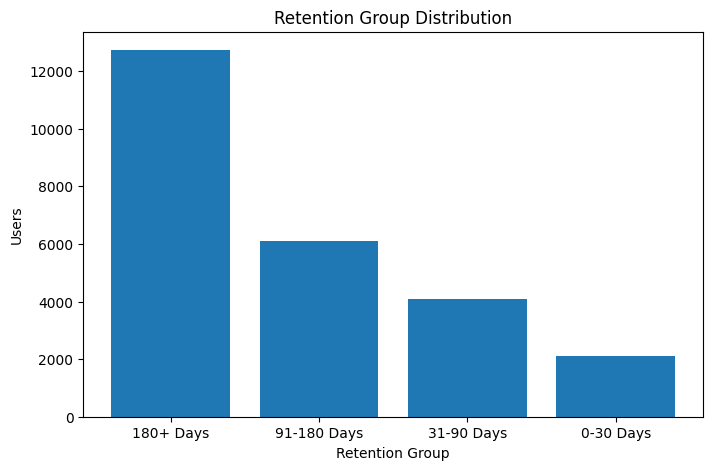

In [34]:
# retention chart

plt.figure(figsize=(8,5))

plt.bar(
    retention_groups.index,
    retention_groups.values
)
plt.title("Retention Group Distribution")
plt.xlabel("Retention Group")
plt.ylabel("Users")
plt.show()

## 26. Highly Engaged Users

This section identifies users with the highest engagement based on sessions and feature usage.

In [35]:
# top engaged users

top_users = df.sort_values(
    by="total_sessions",
    ascending=False
)[[
    "user_id",
    "total_sessions",
    "feature_usage_count",
    "avg_session_duration"
]].head(10)

top_users

,user_id,total_sessions,feature_usage_count,avg_session_duration
23562,23563,499,100,15.99
5897,5898,499,14,19.61
1358,1359,499,199,27.38
23669,23670,499,148,46.43
18646,18647,499,99,17.45
9880,9881,499,124,25.73
16827,16828,499,108,8.94
574,575,499,104,38.16
12765,12766,499,67,22.60
15796,15797,499,36,26.23


## 27. Key Insights

The following insights were identified from the SaaS product funnel analysis:

### Funnel Insights
- A noticeable drop-off exists between user signup and onboarding completion stages.
- Only a portion of users successfully convert into premium subscribers.

### Engagement Insights
- Users with higher session counts and longer session durations show better retention behavior.
- Certain product features receive significantly higher adoption compared to others.

### Churn Insights
- Churned users generally demonstrate lower engagement and lower session activity.
- Device type and traffic source influence churn behavior.

### Revenue Insights
- Premium and enterprise plan users contribute the majority of platform revenue.
- Some traffic sources generate significantly higher monetization performance.

### Retention Insights
- Users with higher retention days tend to engage more frequently with the platform.
- Long-term retained users demonstrate stronger onboarding completion behavior.

## 28. Final Business Recommendations

Based on the analysis, the following recommendations are suggested:

- Improve onboarding experience to reduce funnel drop-offs.
- Increase engagement campaigns for low-activity users.
- Promote highly adopted features during onboarding.
- Focus marketing investment on high-performing traffic sources.
- Introduce retention campaigns for users with declining engagement.
- Encourage premium upgrades using targeted feature recommendations.
- Improve mobile user experience to reduce churn rates.
- Use behavioral segmentation for personalized product experiences.

## 29. Conclusion

This project successfully analyzed user behavior across a SaaS product funnel using synthetic product analytics data.

The analysis covered:
- onboarding behavior
- user engagement
- churn analysis
- retention analysis
- subscription conversion
- revenue insights
- feature adoption trends

The project demonstrates how data analytics can be used to identify product bottlenecks, optimize conversion funnels, improve retention, and support business decision-making in SaaS environments.